In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sys
import os

sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from src.preprocessing import (
    load_data,
    clean_data,
    create_features
)

In [3]:
DATA_PATH = "../data/customer_churn.csv"

df = load_data(DATA_PATH)

df = clean_data(df)
df = create_features(df)

df = df.drop("customerID", axis=1)

X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 24)
y shape: (7043,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5634
Testing samples: 1409


In [5]:
logistic_model = joblib.load(
    "../models/logistic_churn_model.pkl"
)

random_forest_model = joblib.load(
    "../models/random_forest_churn_model.pkl"
)

print("Models loaded successfully.")

Models loaded successfully.


In [6]:
logistic_pred = logistic_model.predict(X_test)

random_forest_pred = random_forest_model.predict(X_test)

In [7]:
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

random_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [8]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_pred
)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Random Forest Accuracy:", random_forest_accuracy)

Logistic Regression Accuracy: 0.8041163946061036
Random Forest Accuracy: 0.7629524485450674


In [9]:
logistic_precision = precision_score(
    y_test,
    logistic_pred
)

random_forest_precision = precision_score(
    y_test,
    random_forest_pred
)

print("Logistic Regression Precision:", logistic_precision)
print("Random Forest Precision:", random_forest_precision)

Logistic Regression Precision: 0.6644295302013423
Random Forest Precision: 0.5471698113207547


In [10]:
logistic_recall = recall_score(
    y_test,
    logistic_pred
)

random_forest_recall = recall_score(
    y_test,
    random_forest_pred
)

print("Logistic Regression Recall:", logistic_recall)
print("Random Forest Recall:", random_forest_recall)

Logistic Regression Recall: 0.5294117647058824
Random Forest Recall: 0.6203208556149733


In [11]:
logistic_f1 = f1_score(
    y_test,
    logistic_pred
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_pred
)

print("Logistic Regression F1:", logistic_f1)
print("Random Forest F1:", random_forest_f1)

Logistic Regression F1: 0.5892857142857143
Random Forest F1: 0.581453634085213


In [12]:
logistic_auc = roc_auc_score(
    y_test,
    logistic_prob
)

random_forest_auc = roc_auc_score(
    y_test,
    random_forest_prob
)

print("Logistic Regression ROC-AUC:", logistic_auc)
print("Random Forest ROC-AUC:", random_forest_auc)

Logistic Regression ROC-AUC: 0.8464103955152549
Random Forest ROC-AUC: 0.8215402102870133


In [13]:
print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    classification_report(
        y_test,
        logistic_pred
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [14]:
print("RANDOM FOREST")
print("=" * 50)

print(
    classification_report(
        y_test,
        random_forest_pred
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.55      0.62      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409



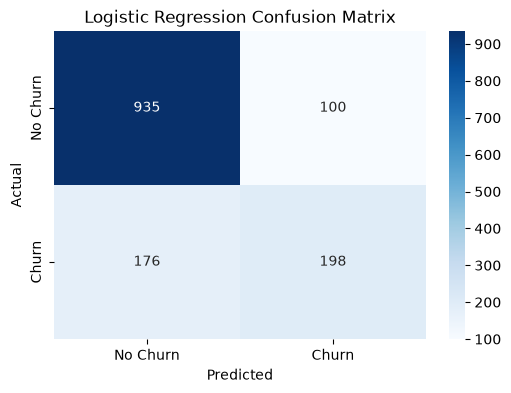

In [15]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

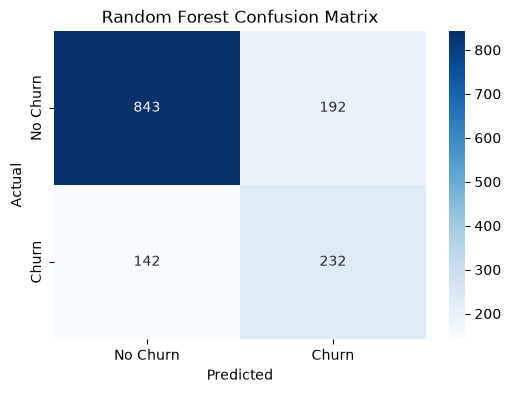

In [16]:
cm_rf = confusion_matrix(
    y_test,
    random_forest_pred
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [17]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    random_forest_prob
)

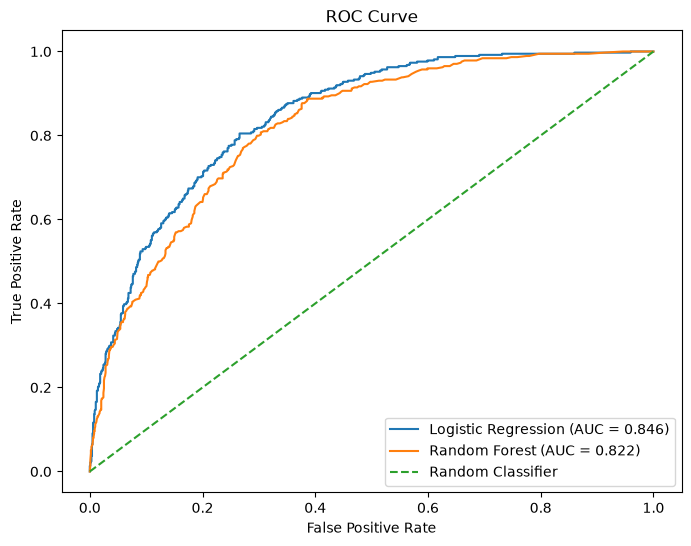

In [18]:
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {random_forest_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [19]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        random_forest_precision
    ],
    "Recall": [
        logistic_recall,
        random_forest_recall
    ],
    "F1 Score": [
        logistic_f1,
        random_forest_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        random_forest_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.66443,0.529412,0.589286,0.84641
1,Random Forest,0.762952,0.54717,0.620321,0.581454,0.82154


In [20]:
results.to_csv(
    "../models/evaluation_results.csv",
    index=False
)

print("Evaluation results saved.")

Evaluation results saved.
